# Evaluación de Modelos
#### Reporte Inmobiliaria · TC2004B — Semana 5

---

**Alumno:** Luis Benvenuto \
**Matrícula:** A01286400 \
**Fecha:** 10 de marzo de 2026 \
**Asignatura:** TC2004B

---

**Contexto del problema**

Una inmobiliaria necesita predecir precios de casas a partir de 5 variables: `sqft`, `bedrooms`, `age`, `distance_downtown`, `luxury`. El modelo se utilizará en tres contextos distintos:

| Uso | Descripción |
|-----|-------------|
| **A** | Valuaciones automáticas en el sitio web|
| **B** | Detección de propiedades subvaluadas para compra estratégica |
| **C** | Reportes mensuales a la junta directiva |

**Dataset `housing_messy.csv`:** 500 observaciones · 5 variables de entrada · `price` en miles de USD.
Características relevantes: 15 casas ultra-lujo ($2M–$5M) entre casas normales ($100K–$400K), heterocedasticidad, valores extremos en `age`, relación no lineal entre `distance_downtown` y `price`.

---

## Código — Entrenamiento de Modelos y Diagnósticos


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
df = pd.read_csv('../../data/s5/housing_messy.csv')

# Split estratificado por quantiles de precio
df['price_bin'] = pd.qcut(df['price'], q=4, labels=False)
X = df.drop(['price', 'price_bin'], axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=df['price_bin']
)

# --- MODELO A: Ridge con alpha=0.1 ---
pipe_a = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=0.1))
])
pipe_a.fit(X_train, y_train)
pred_a = pipe_a.predict(X_test)

# --- MODELO B: Ridge con alpha=10 ---
pipe_b = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=10))
])
pipe_b.fit(X_train, y_train)
pred_b = pipe_b.predict(X_test)

# --- MODELO C: Lasso con alpha=5 ---
pipe_c = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=5))
])
pipe_c.fit(X_train, y_train)
pred_c = pipe_c.predict(X_test)

# --- MODELO D: Ridge sin casas de ultra-lujo ---
mask_train = y_train < 1000  # Solo casas <$1M
mask_test = y_test < 1000

pipe_d = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1))
])
pipe_d.fit(X_train[mask_train], y_train[mask_train])
pred_d = pipe_d.predict(X_test[mask_test])

# Función para calcular métricas
def evaluate_model(y_true, y_pred, name):
    print(f"\n=== {name} ===")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"R2: {r2_score(y_true, y_pred):.3f}")
    
    # MAPE (cuidado con valores pequeños)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"MAPE: {mape:.2f}%")
    
    # Percentil 95 del error absoluto
    p95 = np.percentile(np.abs(y_true - y_pred), 95)
    print(f"95th percentile |error|: {p95:.2f}")

# Evaluar todos
evaluate_model(y_test, pred_a, "Modelo A: Ridge(alpha=0.1)")
evaluate_model(y_test, pred_b, "Modelo B: Ridge(alpha=10)")
evaluate_model(y_test, pred_c, "Modelo C: Lasso(alpha=5)")
evaluate_model(y_test[mask_test], pred_d, "Modelo D: Ridge sin casas de lujo")


=== Modelo A: Ridge(alpha=0.1) ===
RMSE: 335.22
MAE: 227.70
R2: 0.807
MAPE: 112.58%
95th percentile |error|: 490.04

=== Modelo B: Ridge(alpha=10) ===
RMSE: 339.62
MAE: 223.67
R2: 0.802
MAPE: 107.28%
95th percentile |error|: 454.63

=== Modelo C: Lasso(alpha=5) ===
RMSE: 336.36
MAE: 224.64
R2: 0.805
MAPE: 109.77%
95th percentile |error|: 472.07

=== Modelo D: Ridge sin casas de lujo ===
RMSE: 40.89
MAE: 32.73
R2: 0.804
MAPE: 18.22%
95th percentile |error|: 79.20


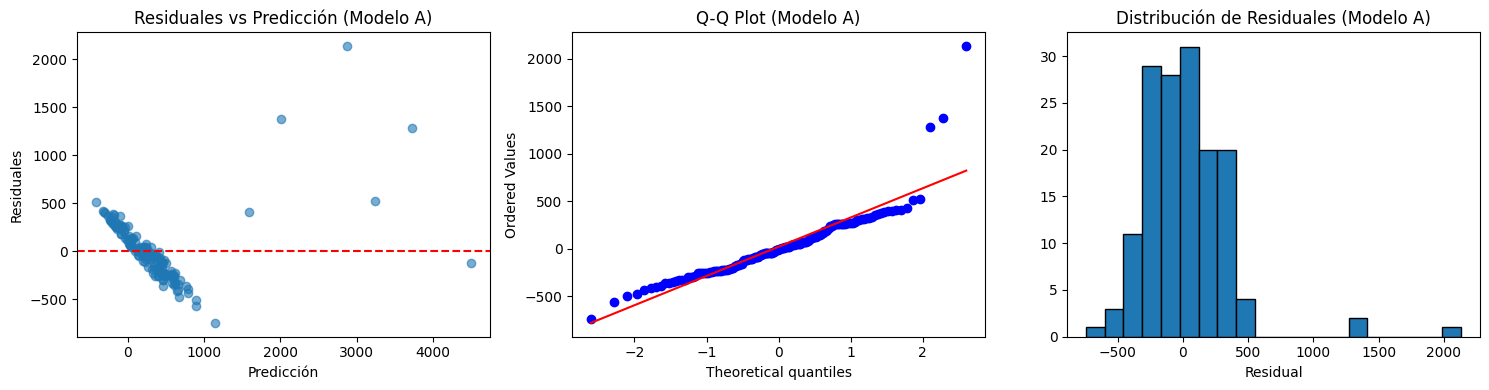

In [6]:
# Diagnósticos para Modelo A
residuals_a = y_test - pred_a

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuales vs predichos
axes[0].scatter(pred_a, residuals_a, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Residuales')
axes[0].set_title('Residuales vs Predicción (Modelo A)')

# Q-Q plot
from scipy import stats
stats.probplot(residuals_a, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Modelo A)')

# Histograma de errores
axes[2].hist(residuals_a, bins=20, edgecolor='black')
axes[2].set_xlabel('Residual')
axes[2].set_title('Distribución de Residuales (Modelo A)')

plt.tight_layout()
plt.show()


---

## Resultados y Análisis

### Resumen de Métricas

| Modelo | RMSE | MAE | R² | MAPE | P95 error |
|---|---|---|---|---|---|
| A: Ridge α=0.1 | 335.22 | 227.70 | 0.807 | 112.58% | 490.04 |
| B: Ridge α=10  | 339.62 | **223.67** | 0.802 | 107.28% | **454.63** |
| C: Lasso α=5   | 336.36 | 224.64 | 0.805 | 109.77% | 472.07 |
| D: Ridge sin lujo | **40.89** | **32.73** | 0.804 | **18.22%** | **79.20** |

*(Modelo D evaluado únicamente sobre casas menores a $1M en el test set)*

---

## Parte 1: Interpretación de Resultados

### 1.1 Modelo A vs. Modelo B: RMSE más bajo pero P95 más alto

El Modelo A tiene menor regularización, lo que le permite ajustarse más a los patrones de entrenamiento, incluyendo los valores extremos de las casas de ultra-lujo. Esto resulta en predicciones más precisas en promedio, de ahí el RMSE un poco menor. Sin embargo, este mismo sobreajuste parcial produce errores catastróficos en casos atípicos: el percentil 95 del error absoluto es 490.04 contra 454.63 del Modelo B. En el 5% más difícil de casos, el Modelo A se equivoca más de $490K.

El Modelo B aplica regularización más fuerte, ya que penaliza coeficientes grandes y produce predicciones más conservadoras y homogéneas. Pierde algo de precisión promedio pero gana consistencia. La diferencia muestra la importancia entre lo que es sesgo y varianza, puesto que el Modelo A tiene menor sesgo, o es más flexible, pero mayor varianza, o con errores más dispersos, mientras que el Modelo B acepta más sesgo a cambio de errores más homogéneos.

En términos prácticos, el Modelo A se equivoca mucho en pocas casas mientras el Modelo B se equivoca moderadamente en todas.

### 1.2 Heterocedasticidad en el Modelo A

La heterocedasticidad no invalida el modelo en el sentido de que las predicciones sean inútiles. Sí invalida ciertos supuestos estadísticos formales, como intervalos de confianza basados en OLS, pero en un contexto de predicción pura el modelo puede seguir siendo útil.

Las implicaciones dependen del uso:

- **Uso A (valuaciones web):** Es problemática. Para casas caras, el modelo se equivoca mucho más, y son precisamente esas transacciones de mayor valor las que generan mayor expectativa de exactitud.

- **Uso B (detección de subvaluadas):** Es menos grave e incluso puede ser informativa. Si el modelo predice $300K para una casa en $800K, eso es una señal de anomalía que merece investigación estratégica. El error grande en casas caras puede ser una señal, no solo ruido.

- **Uso C (reportes a junta):** Debe comunicarse explícitamente. Los reportes deben incluir intervalos de predicción diferenciados por segmentos de precio, no un único número del error. La junta necesita saber que el modelo es menos confiable en el segmento premium.

### 1.3 Modelo D, mejor MAPE pero entrenado sin lujo

El Modelo D tiene MAPE de 18.22% contra 107 a 112% de los demás, y RMSE de 40.89 contra 335 a 340. La diferencia es espectacular, pero hay que leerla con cuidado, ya que se trata de una comparación diferente. El Modelo D se evalúa solo sobre las casas normales del test set, mientras que los demás se evalúan sobre todo el test set incluyendo las 15 casas de lujo que dominan las métricas de error.

Es válido reportarlo, pero con esa aclaración explícita. No es honesto compararlo directamente contra los otros sin indicar que opera sobre un subconjunto diferente.

Se debería usar solo si el negocio confirma que el modelo nunca verá casas de lujo, entonces el Modelo D es claramente superior para ese segmento. Si el sistema puede recibir cualquier casa, Modelo D simplemente no sabe qué hacer con las de lujo y sus predicciones serían no confiables ahí.

---

## Parte 2: Decisión Justificada

### 2.1 Memo — Elección de Métrica Principal

**Para:** Directora Técnica  
**De:** Consultor
**Asunto:** Recomendación de métrica principal para evaluación de modelos de valuación

---

Recomiendo el MAE (Error Absoluto Medio) como métrica principal, con el percentil 95 del error absoluto como métrica secundaria obligatoria.

**¿Por qué MAE?**

El RMSE eleva los errores al cuadrado, lo que significa que las 15 casas de ultra-lujo dominan completamente la métrica. Con una distribución de precios tan sesgada, el RMSE mide básicamente qué tan mal le va al modelo en las casas de lujo, no qué tan bien funciona en el 97% de las transacciones.

El MAE, al promediar errores absolutos sin elevarlos al cuadrado, representa mejor el error típico que un cliente promedio experimentaría. Un MAE de $223-227K significa que, en el día a día, el modelo se equivoca en ese rango en promedio. Es un número que la directora puede comunicar al equipo de producto con claridad.

El MAPE sería ideal en otros casos, pero aquí es inútil. Los valores de 107-112% están distorsionados por las casas de lujo donde el modelo falla por márgenes que superan el precio de casas normales.

El R² no diferencia suficientemente entre modelos para ser discriminante y no tiene interpretación directa de negocio.

**Limitaciones de mi elección:**  
El MAE trata igual un error de $200K en una casa de $150K que en una casa de $2M. No captura la gravedad relativa del error. Tampoco penaliza los errores extremos, que son precisamente los que dañan la reputación.

**Métricas secundarias recomendadas:**
- Percentil 95 del error absoluto: captura los casos más problemáticos, complementa el MAE.
- Error relativo mediano por segmento de precio: separa el desempeño en casas baratas, medias y de lujo.
---

### 2.2 Selección de Modelo para Producción

**Recomiendo el Modelo B (Ridge α=10) como modelo principal de producción.**

**Justificación:**

El Modelo B tiene el MAE más bajo (223.67) y el percentil 95 más bajo (454.63 vs 490.04 del Modelo A). El 95% de las valuaciones del Modelo B tendrán un error menor a $454K. El Modelo A mejora apenas 4 dólares en MAE a costa de errores más extremos en los peores casos. Ese intercambio no vale la pena.

La regularización fuerte del Modelo B produce coeficientes más estables, lo que significa que el modelo generalizará mejor a propiedades que no vio en entrenamiento. Dado que el portafolio de la inmobiliaria cambiará con el tiempo y esta robustez tiene valor más allá de las métricas actuales.

**Modelos descartados y por qué:**

- **Modelo A (Ridge α=0.1):** Descartado. El pequeño ahorro en RMSE no justifica la mayor varianza en errores extremos. El percentil 95 de 490K representa $35K más de error en el 5% peor de casos contra el Modelo B. En valuaciones públicas, ese 5% causará incidentes de soporte.

- **Modelo C (Lasso α=5):** Descartado. Métricas intermedias sin ventaja clara sobre B. Lasso puede anular variables completas, lo cual podría ser útil para interpretabilidad, pero no hay evidencia de que simplifique el modelo sin costo en precisión aquí. Si la interpretabilidad fuera crítica, Lasso valdría investigar más.

- **Modelo D (Ridge sin lujo):** No es válido como modelo general de producción porque fue entrenado sin un segmento completo del mercado. Sería un modelo de nicho para un producto específico de casas estándar si la empresa decide segmentar explícitamente.

**Adecuación por uso:**

- **Uso A (valuaciones web):** El Modelo B es la mejor opción disponible de los cuatro. Aunque un error promedio de $223K en un mercado donde la mediana de precio es probablemente $200 a 250K es enorme. El equipo de producto debe mostrar rangos en lugar de un número exacto, e indicar que el modelo es menos preciso para casas de lujo.

- **Uso B (compra estratégica):** El Modelo B es aceptable pero subóptimo. La regularización fuerte suaviza las anomalías de precio que queremos detectar. Para este uso específico, recomendaría evaluar el Modelo A como alternativa, aceptando los errores extremos porque en este contexto los errores grandes en casas caras pueden ser señales, no ruido.

- **Uso C (reportes a junta):** El Modelo B es apropiado. Los errores consistentes son más fáciles de comunicar y de incluir en intervalos de confianza. La junta puede confiar en un modelo que siempre se equivoca en un rango similar más que en uno que a veces es exacto y a veces fallido por $490K.

**Riesgos de la elección:**

1. El RMSE del Modelo B es 1.3% mayor que el A. Si los dashboards internos reportan RMSE como KPI principal, el Modelo B se verá peor aunque sea la decisión correcta.
2. Ambos modelos asumen una relación lineal entre features y precio. La relación no lineal entre `distance_downtown` y precio no está capturada, lo que puede producir errores sistemáticos para propiedades en ciertos rangos de distancia.
3. El modelo no fue entrenado con datos de tiempo. Si los precios del mercado cambian, las predicciones quedarán desactualizadas. Se necesita re-entrenamiento periódico.

**Lo que le diría al equipo de producto:** El modelo es una referencia. Para el segmento de lujo, los errores son mayores. REcomendaría mostrar siempre un intervalo de predicción, indicar el segmento de confianza del modelo, y habilitar que los agentes inmobiliarios puedan sobrescribir la valuación automática con su criterio profesional.

---

## Parte 3: Pensamiento Crítico

### 3.1 El caso de las casas de ultra-lujo

**No estoy de acuerdo con eliminarlas simplemente porque son outliers.**

Un outlier en el sentido estadístico es una observación que no pertenece a la distribución oculta. Las 15 casas de $2M-$5M no son errores sino que son propiedades reales que la inmobiliaria probablemente quiere valuar. Eliminarlas sin justificación de negocio es tomar una decisión implícita de que el modelo no aplica para ese segmento, sin decírselo a nadie.

**Si las eliminas, estás asumiendo:**
- Que el modelo nunca verá casas de lujo en producción.
- Que las casas de lujo siguen las mismas reglas pero con valores más altos.
- Que mejorar las métricas promedio es más importante que cubrir todo el mercado.

Si hay una solución mejor que es segmentar el mercado explícitamente. Entrenar dos modelos separados. Uno para el mercado estándar y otro para el segmento de lujo. El modelo de lujo podría requerir más características que no están disponibles aquí, lo que podría llevar a la conclusión de que el lujo necesita valuación humana asistida por modelo, no automática.

Otra opción es transformar la variable objetivo para reducir el efecto de escala en el entrenamiento, o usar un modelo más robusto a outliers como Huber regression.

**¿Cambia la respuesta según el uso?**

- **Uso A:** Si la web de valuaciones nunca mostrará casas de lujo, eliminarlas del entrenamiento tiene sentido. Pero hay que ser explícito, puesto que el sistema debe rechazar o redirigir casas con precio probable >$1M.

- **Uso B:** No, definitivamente no eliminarlas. Detectar casas subvaluadas en el segmento de lujo es donde el valor de negocio es más alto. Una casa de lujo comprada por $1.5M y revendida en $3M es mucho más interesante que una normal comprada en $150K y revendida en $180K.

- **Uso C:** La junta directiva probablemente quiere ver el panorama completo del portafolio, incluyendo lujo. Eliminarlas sesgaría los reportes y podría llevar a decisiones estratégicas incorrectas.

---

### 3.2 Data Leakage — Grid Search en Test Set

**Sí, hay un problema que es data leakage en la evaluación.**

Cuando se probó 50 valores de alpha y eligió el que produce R²=0.891 en el test set, el test set dejó de ser independiente. El proceso de selección de hiperparámetros usó información del test set  para tomar decisiones de modelado. El R²=0.891 es un estimado optimistamente sesgado del rendimiento real del modelo.

El test set debe tocarse exactamente una vez, al final, para reportar el rendimiento final. Usarlo 50 veces lo convierte funcionalmente en un validation set. 
La solución correcta es:
1. Dividir en tres conjuntos: train, validation y test.
2. O usar cross-validation en el train set para seleccionar alpha.
3. El test set se reserva para el reporte final, y ese número se reporta como definitivo.

Si el colega reporta R²=0.891 sin aclarar que fue elegido después de evaluar 50 modelos en ese mismo test set, está sobreestimando el rendimiento real. En producción, el modelo probablemente tendrá R² considerablemente menor. Esto no es deshonestidad intencional, es un error metodológico común, pero tiene consecuencias reales si la empresa toma decisiones basadas en ese dato.

---

### 3.3 El dilema del percentil

Con información únicamente sobre la distribución de errores elegiría diferente según el contexto de uso:

**La gravedad de equivocarse mucho en pocos casos depende de quién está en ese 5%.**

Si el 5% de errores extremos del Modelo A corresponde a casas de ultra-lujo, entonces el error absoluto puede ser enorme pero el error relativo podría ser tolerable, o incluso esperado. Una predicción de $500K para una casa de $3M tiene un error absoluto alto pero la empresa ya sabe que ese segmento es difícil. El daño reputacional es alto pero quizás el negocio puede manejarlo.

Si el 5% de errores extremos afecta casas normales de $150K, eso es mucho más grave, ya que son los clientes más vulnerables, con menos capacidad de tolerar una valuación incorrecta, y el daño de confianza es más difícil de recuperar.

**Decisión por uso:**

- **Uso A (valuaciones web):** Elegiría Modelo B. Los errores consistentes permiten al equipo de UX mostrar rangos calibrados con confianza. Un 5% de casos extremos genera cola de soporte y reseñas negativas que dañan la marca de forma desproporcionada. Prefiero consistencia sobre precisión promedio cuando el cliente final ve el número directamente.

- **Uso B (compra estratégica):** Elegiría Modelo A. El 5% de errores extremos puede ser precisamente el 5% de oportunidades. Analistas internos con contexto de negocio pueden interpretar esas anomalías, no clientes finales. Aquí la varianza del modelo es un feature, no un bug.

- **Uso C (reportes a junta):** Elegiría Modelo B. La junta toma decisiones estratégicas basadas en promedios y tendencias. Los errores consistentes producen reportes más estables entre períodos. Un outlier de predicción en el Modelo A podría distorsionar un reporte mensual completo si cae en ese mes.

**Conclusión general:** No existe una respuesta universal. La elección entre precisión promedio y consistencia de errores es una decisión de negocio, no de estadística. Lo que sí es claro es que el Modelo B es más robusto y más fácil de defender ante stakeholders no técnicos, lo que tiene valor organizacional más allá de las métricas.